In [33]:
import os
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI

from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_classic.output_parsers import PydanticOutputParser, OutputFixingParser
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver


import operator
import sqlite3
import json
import requests
from bs4 import BeautifulSoup

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_classic.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun, DuckDuckGoSearchRun,tool
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [22]:
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")

In [ ]:
## Initializing LLMs

# Using models known to work well with structured output
ollama_gpt = ChatOllama(model='gpt-oss:120b-cloud')
llama4_llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
qwen_llm = ChatGroq(model="qwen/qwen3-32b")      prompt = f"""  prompt = f"""
google_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
openai_llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OllamaEmbeddings(model="qwen3-embedding:8b")

# Creating a fallback LLM that tries multiple    prompt = f""" models in order until it gets a valid response
fallback_llm = ollama_gpt.with_fallbacks([llama4_llm,qwen_llm,google_llm])

In [17]:
## Load the document
loader = PyPDFLoader("/home/prashant/Documents/gen-ai/LangGraph/intro-to-ml.pdf")
docs = loader.load()

## Chunking
splittrer = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=225)
doc_chunks = splittrer.split_documents(docs)
print(f"Number of document chunks: {len(doc_chunks)}")

Number of document chunks: 666


In [18]:
## Creating the vectorstore
vectorstore = FAISS.from_documents(doc_chunks, embeddings)
vectorstore

In [19]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 4}, search_type="mmr")
retriever.invoke("Why we use Python for machine learning?")

[Document(id='597ab0e6-b821-4f09-b96c-e163a6b99ff0', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': '/home/prashant/Documents/gen-ai/LangGraph/intro-to-ml.pdf', 'total_pages': 392, 'page': 2, 'page_label': 'i'}, page_content='Andreas C. Müller and Sarah Guido\nIntroduction to Machine Learning\nwith Python\nA Guide for Data Scientists\nBoston Farnham Sebastopol TokyoBeijing Boston Farnham Sebastopol TokyoBeijing'),
 Document(id='6b313d4e-9baa-4ecb-86a6-defda9acac51', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/

In [ ]:
## New RAG tool added in case any answer asked from the document
@tool
def rag_tool(query: str):
    """
    Retrieve relevant information from the PDF documents,
    use this tool when user ask a question which would be conceptual/factial
    that might be answered from the relevant documents.
    
        Args:
            query: The question or query for which relevant information is to be retrieved.
    """
    result = retriever.invoke(query)

    context = [res.page_content for res in result]
    metadata = [res.metadata for res in result]

    return {
        'query':query,
        'context':context,
        'metadata': metadata
    }    

In [ ]:
## Also merging the all other tools created earlier
@tool
def calculator(num1: float, num2: float, operation: Literal['add', 'subtract', 'multiply', 'divide']) -> float:
    """Calculate different operations on two numbers."""
    if operation == 'add':
        return operator.add(num1, num2)
    elif operation == 'subtract':
        return operator.sub(num1, num2)
    elif operation == 'multiply':
        return operator.mul(num1, num2)
    elif operation == 'divide':
        if num2 == 0:
            raise ValueError("Cannot divide by zero")
        return operator.truediv(num1, num2)

@tool
def get_stock_price(symbol: str)->dict:
    """
    fetch the latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha vantage using the URL with API key.
    """
    import requests
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")
    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}'
    response = requests.get(url)
    data = response.json()
    if "Global Quote" in data:
        return {"symbol": symbol, 
                "today_price": data["Global Quote"]["05    prompt = f""". price"],
                "last_price": data["Global Quote"]['02. open'],
                "change": data["Global Quote"]['09. change'],
                "change_percent": data["Global Quote"]['10. change percent']}
    else:
        raise ValueError(f"Could not fetch stock price for symbol: {symbol}")

@tool
def get_url_content(url: str) -> str:
    """
    CRITICAL: Use this tool ONLY when the user provides an exact website URL link 
    (starting with http:// or https://) and asks to extract information directly from it.
    
    DO NOT use Wikipedia or DuckDuckGo if a specific direct URL is provided. 
    Input must be a single, valid, raw URL string.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return f"Error: Webpage returned status code {response.status_code}"
            
        soup = BeautifulSoup(response.text, "html.parser")
        
        # --- FIXING THE HTML SNIPPET ISSUE ---
        # If it's Google Scholar, extract just the authors so we don't dump raw HTML to the LLM
        if "scholar.google" in url:
            for field in soup.find_all("div", class_="gsc_oci_field"):
                if "Authors" in field.get_text():
                    value_div = field.find_next_sibling("div", class_="gsc_oci_value")
                    if value_div:
                        return f"Data successfully extracted from URL. Authors: {value_div.get_text(strip=True)}"
            return "Connected to Google Scholar, but could not find the Authors block."
            
        # For any other general website, strip out the HTML tags and return pure text
        # This stops the LLM from getting drowned in `<!DOCTYPE html>` codes
        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose() 
        return f"Webpage content text: {soup.get_text()[:2000]}" # Limit characters to save tokens
        
    except Exception as e:
        return f"An error occurred while fetching the URL: {str(e)}"

wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=250)    
wikipedia_tool = WikipediaQueryRun(api_wrapper=wikipedia_wrapper)

arxiv_wrapper = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=250)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

web_search_tool = DuckDuckGoSearchRun(region="us-en", top_k_results=3, doc_content_chars_max=250)

tools = [calculator, get_stock_price, rag_tool]

In [56]:
## bind tools
tool_llm = fallback_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

def chat_node(state: ChatState) -> ChatState:
    # Get the last human message
    last_message = state['messages']
    
    # Generate a response using the fallback LLM
    response = tool_llm.invoke(last_message)
    
    return {'messages': [response]}

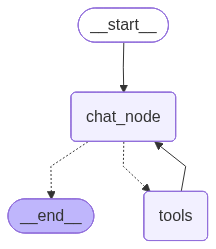

In [58]:
## Creating a checkpoint --> InMemoryStore()
from langgraph.checkpoint.memory import InMemorySaver

#checkpoit
check_point = InMemorySaver()

# build graph
graph = StateGraph(ChatState)

# build nodes
graph.add_node('chat_node', chat_node)
graph.add_node('tools',tool_node)

#build edges
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

# compile
chatbot = graph.compile(checkpointer=check_point)

#visualize
chatbot

In [59]:
## Implementing the Config for the different threads
import uuid

def generate_thread_id():
    return str(uuid.uuid4())


# also implemented a thread list, to store and check the state later
thread_list = []
thread_id = generate_thread_id()
thread_list.append(thread_id)

# Config
CONFIG = {'configurable': {'thread_id': thread_id}}

In [ ]:
print("\n--- To exit, type 'exit', 'quit', or 'bye' ---")
while True:
    user_input = input("Please type here: ")
    print("User message:", user_input)

    if user_input.strip().lower() in ['exit', 'quit', 'bye', 'thanks']:
        print("Goodbye!")
        break
    
    print("Assistant: ", end="", flush=True)
    for msg_chunk, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config=CONFIG,
        stream_mode="messages"  # streams LLM tokens
    ):
        if msg_chunk.content:
            print(msg_chunk.content, end="", flush=True)
    
    print("\n" + "---"*30 + '\n\n')


--- To exit, type 'exit', 'quit', or 'bye' ---
User message: Using the pdf notes, explain how to find the ideal value of K in KNN
Assistant: {"query": "ideal value of K in KNN pdf notes", "context": ["inference, 363\ninformation leakage, 310\ninformation retrieval (IR), 325\ninteger features, 218\n\"intelligent\" applications, 1\ninteractions, 34, 224-232\nintercept_ attribute, 47\niris classification application\ndata inspection, 19\ndataset for, 14\ngoals for, 13\nk-nearest neighbors, 20\nmaking predictions, 22\nmodel evaluation, 22\nmulticlass problem, 26\noverview of, 23\ntraining and testing data, 17\niterative feature selection, 240\nJ\nJupyter Notebook, 7\nK\nk-fold cross-validation, 252\nk-means clustering\napplying with scikit-learn, 170\nvs. classification, 171\ncluster centers, 169\ncomplex datasets, 179\nevaluating and comparing, 191\nexample of, 168\nfailures of, 173\nstrengths and weaknesses, 181\nvector quantization with, 176\nk-nearest neighbors (k-NN)\nanalyzing KNeig